# HOMEWORK 2
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 5]

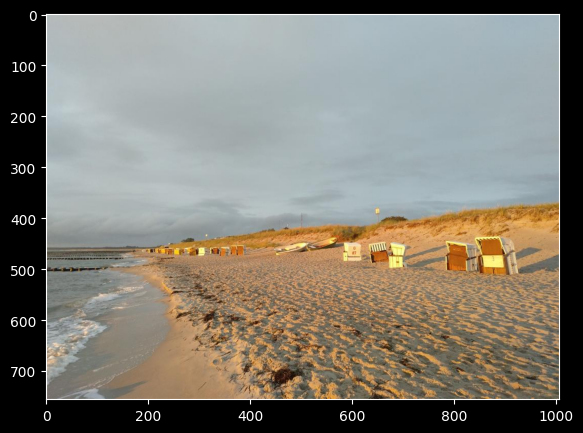

In [2]:
img = cv2.imread('../data/SeaBeach.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

(<Axes: >, <matplotlib.image.AxesImage at 0x17c133842d0>)

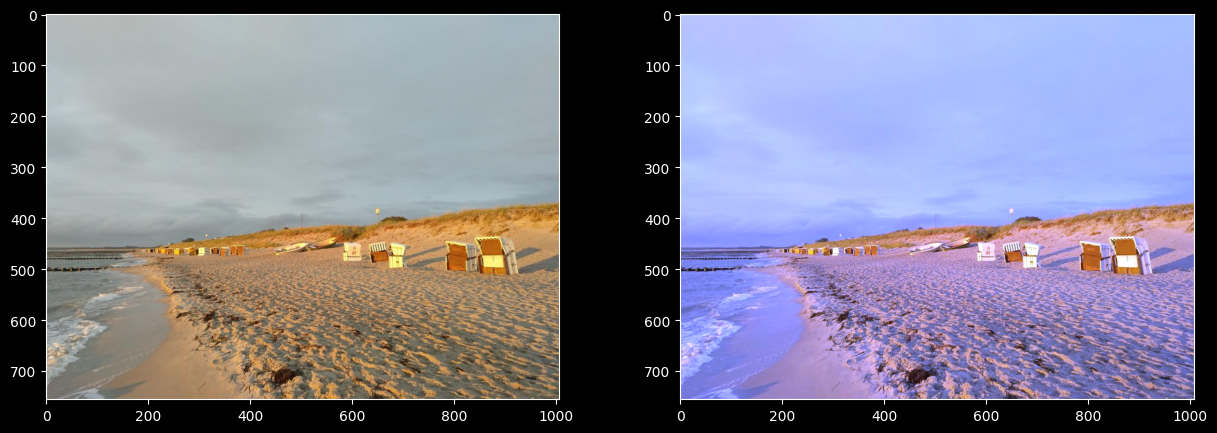

In [3]:
# Define white patch and the coefficients
row, col = 485, 864 
white = img[row, col, :]
coeffs = 255.0/white

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Gray world
This algorithm assumes that a scene, on average, is gray.

(<Axes: >, <matplotlib.image.AxesImage at 0x17c14620b90>)

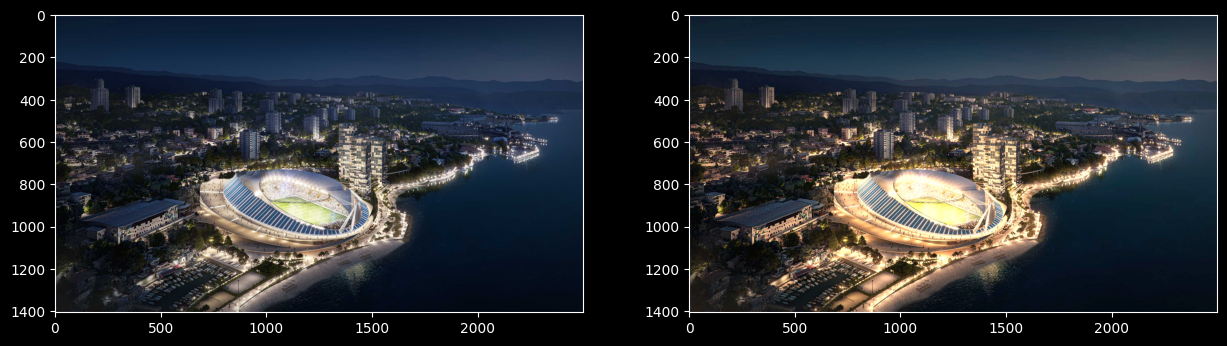

In [4]:
# Load your image
path = '../data/Rijeka-Stadium-Kantrida.jpg'
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the mean values for all three colour channels (red, green, blue)
mean_r = np.mean(img[..., 0]) # 113.32151475694444
mean_g = np.mean(img[..., 1]) # 64.50888647762346
mean_b = np.mean(img[..., 2]) # 38.81509452160494

means = np.array([mean_r, mean_g, mean_b], dtype=np.float64)
brightest_idx = np.argmax(means)
brightest_mean = means[brightest_idx]

# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remining two
# Hint: You can fix the coefficient of the brightest colour channel to 1.

if brightest_idx == 0:      # Red brightest
    kr = 1.0
    kg = brightest_mean / mean_g
    kb = brightest_mean / mean_b
elif brightest_idx == 1:    # Green brightest
    kg = 1.0
    kr = brightest_mean / mean_r
    kb = brightest_mean / mean_b
else:                       # Blue brightest
    kb = 1.0
    kr = brightest_mean / mean_r
    kg = brightest_mean / mean_g

coeffs = np.array([kr, kg, kb], dtype=np.float64)

# Apply color balancing and generate the balanced image
balanced = img.astype(np.float64) * coeffs
balanced = np.clip(balanced, 0, 255).astype(np.uint8)

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

([<matplotlib.lines.Line2D at 0x17c13cba3c0>], None)

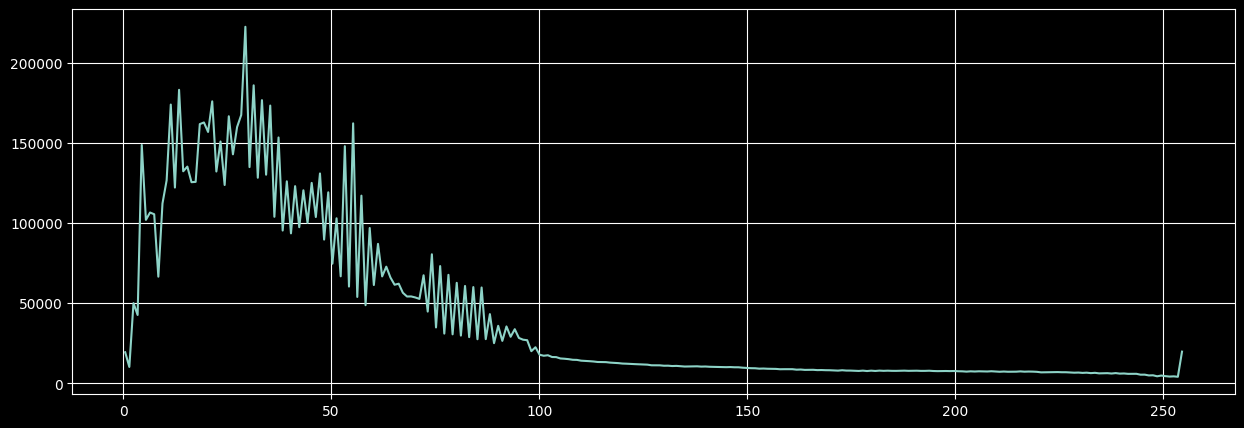

In [5]:
hist, bins = np.histogram(img.ravel(), bins=256, range=(0,255))
plt.plot(bins[0:-1]+0.5, hist), plt.grid(True)

([<matplotlib.lines.Line2D at 0x17c13d22900>], None)

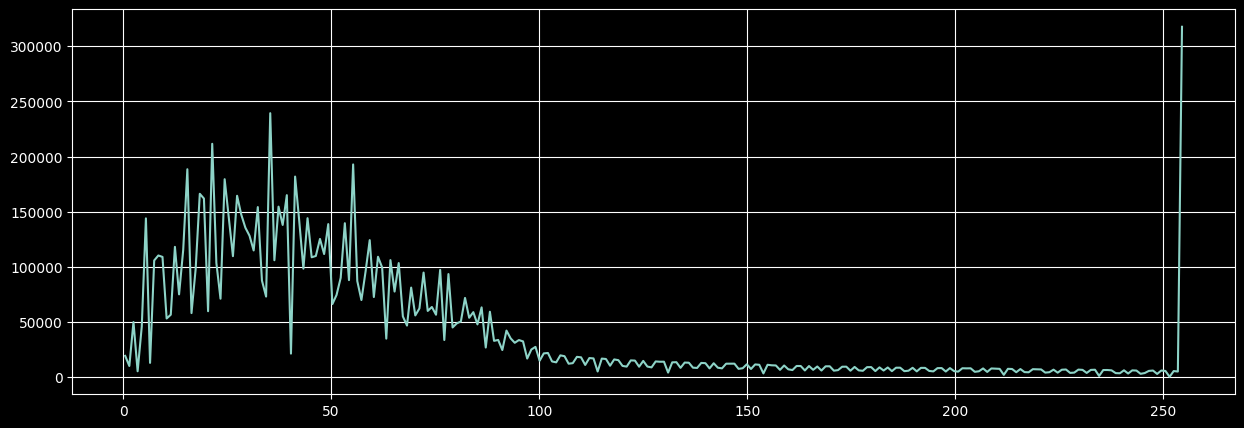

In [6]:
hist, bins = np.histogram(balanced.ravel(), bins=256, range=(0,255))
plt.plot(bins[0:-1]+0.5, hist), plt.grid(True)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

(<Axes: >, <matplotlib.image.AxesImage at 0x17c13e35bd0>)

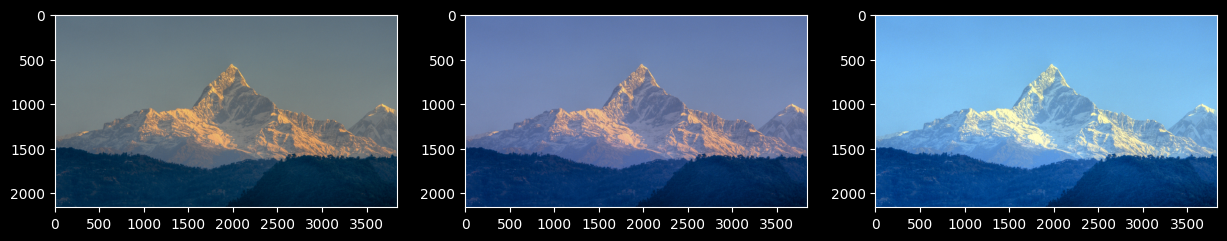

In [7]:
# Load your image

path = '../data/everest.jpg'
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the maximum values for all three colour channels (red, green, blue)
max_r = np.max(img[..., 0]) # 255
max_g = np.max(img[..., 1]) # 255
max_b = np.max(img[..., 2]) # 255

kr = 255.0 / max_r if max_r > 0 else 1.0
kg = 255.0 / max_g if max_g > 0 else 1.0
kb = 255.0 / max_b if max_b > 0 else 1.0

# Apply scale-by-max balancing and generate the balanced image
coeffs = np.array([kr, kg, kb], dtype=np.float64)

# Apply color balancing and generate the balanced image
balanced = img.astype(np.float64) * coeffs
balanced = np.clip(balanced, 0, 255).astype(np.uint8)

# If image contains all colors with max color 255, we can choose quantiles as alternative.
max_q_r = np.quantile(img[..., 0], 0.99)
max_q_g = np.quantile(img[..., 1], 0.99)
max_q_b = np.quantile(img[..., 2], 0.99)

krq = 255.0 / max_q_r if max_q_r > 0 else 1.0
kgq = 255.0 / max_q_g if max_q_g > 0 else 1.0
kbq = 255.0 / max_q_b if max_q_b > 0 else 1.0

coeffs_quantile = np.array([krq, kgq, kbq], dtype=np.float64)

balanced_quantile_99 = img.astype(np.float64) * coeffs_quantile
balanced_quantile_99 = np.clip(balanced_quantile_99, 0, 255).astype(np.uint8)

plt.subplot(131), plt.imshow(img)
plt.subplot(132), plt.imshow(balanced)
plt.subplot(133), plt.imshow(balanced_quantile_99)

([<matplotlib.lines.Line2D at 0x17c13f0da90>], None)

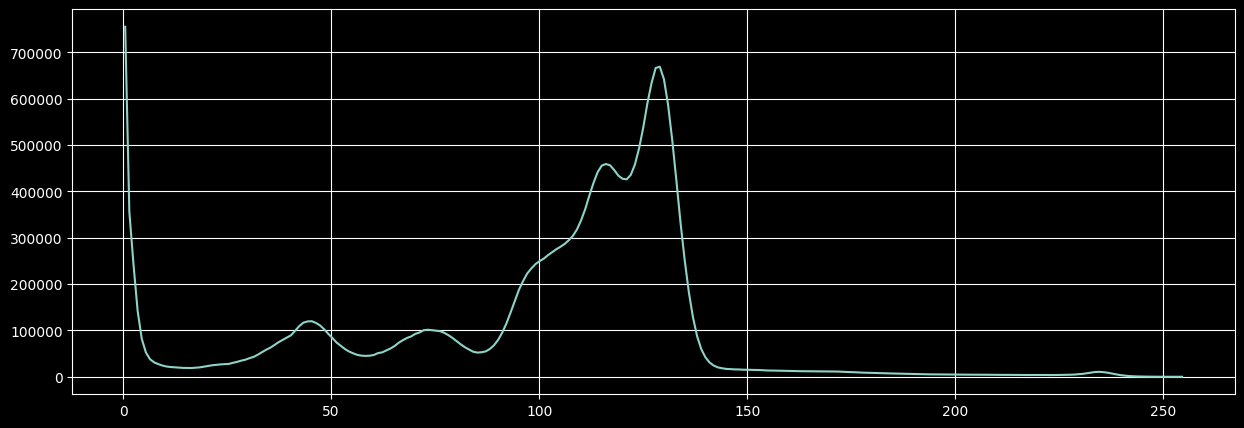

In [8]:
hist, bins = np.histogram(img.ravel(), bins=256, range=(0,255))
plt.plot(bins[0:-1]+0.5, hist), plt.grid(True)

([<matplotlib.lines.Line2D at 0x17c14b5eba0>], None)

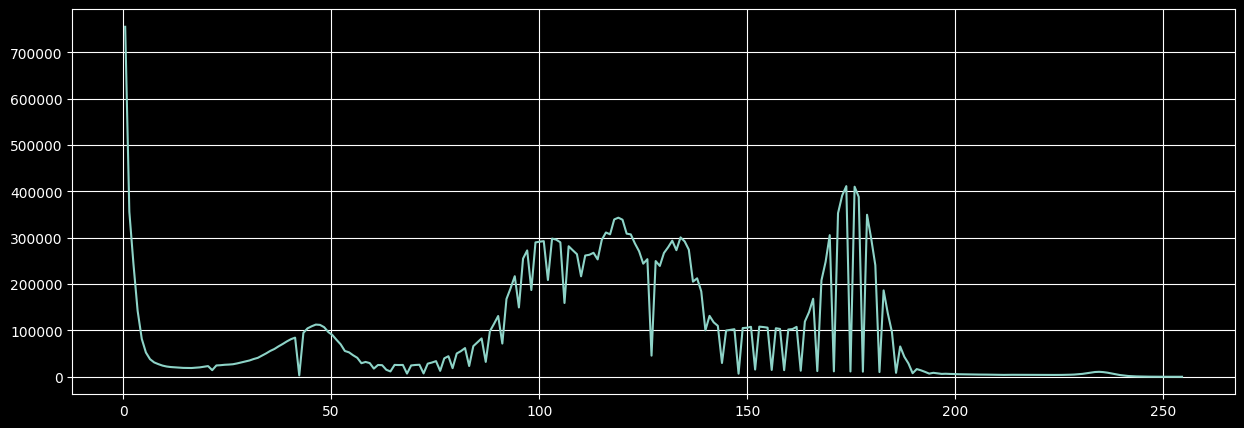

In [9]:
hist, bins = np.histogram(balanced.ravel(), bins=256, range=(0,255))
plt.plot(bins[0:-1]+0.5, hist), plt.grid(True)

([<matplotlib.lines.Line2D at 0x17c14bc7cb0>], None)

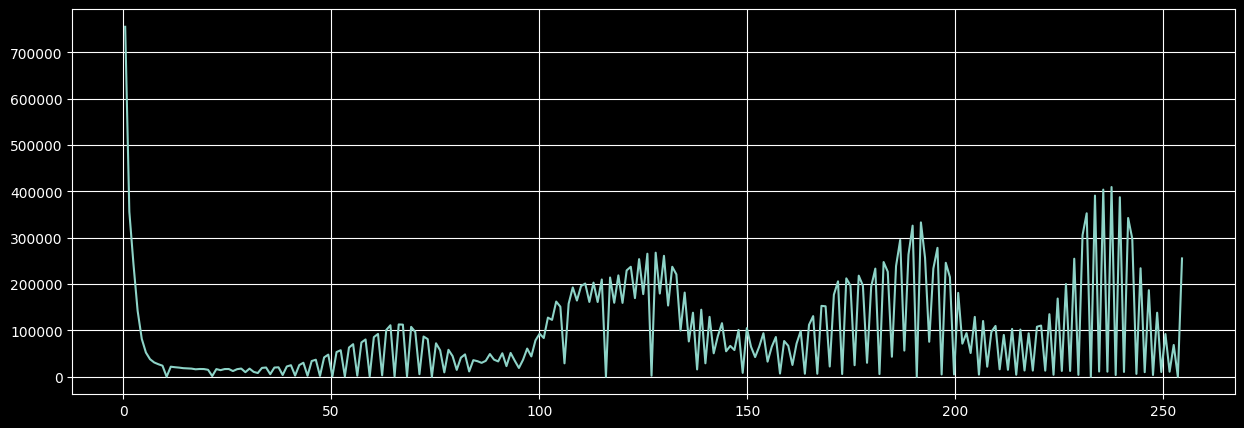

In [10]:
hist, bins = np.histogram(balanced_quantile_99.ravel(), bins=256, range=(0,255))
plt.plot(bins[0:-1]+0.5, hist), plt.grid(True)